---
title: Datos Secuenciales y sus Desafíos
subject: Aprendizaje Profundo
subtitle: 
short_title: Desafíos de los datos secuenciales
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorgeanais/libro_aprendizaje_profundo/blob/main/cap3/010_motivacion_secuencias.ipynb)

**Objetivo**: Ilustrar el problema fundamental que plantean las secuencias de largo variable usando cantos de aves chilenas como caso de estudio, y mostrar por qué las redes tradicionales (MLP) no son una solución adecuada para este tipo de datos.

## Preparativos

In [1]:
import sys
import numpy as np
import torch
import torch.nn as nn
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import soundfile as sf
from pathlib import Path

print(f'Python {sys.version}')
print(f'PyTorch {torch.__version__}')
print(f'Librosa {librosa.__version__}')

Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch 2.10.0+cpu
Librosa 0.11.0


## Carga de datos

Cargamos ocho grabaciones de aves chilenas. Si estás en Colab, sube los archivos `.flac` usando el panel de archivos antes de ejecutar esta celda.

In [2]:
BIRD_FILES = {
    'Cachudito':         'cachudito.flac',
    'Chercan':           'chercan.flac',
    'Chincol':           'chincol.flac',
    'Golondrina Chilena':'golondrina_chilena.flac',
    'Mirlo':             'mirlo.flac',
    'Rara':              'rara.flac',
    'Tenca Chilena':     'tenca_chilena.flac',
    'Zorzal':            'zorzal.flac',
}

SR = 44100  # frecuencia de muestreo original

bird_audio = {}
for name, fname in BIRD_FILES.items():
    y, sr = librosa.load(fname, sr=SR, mono=True)
    bird_audio[name] = y
    print(f'{name:22s}  duración={len(y)/sr:.2f}s  muestras={len(y):,}')

Cachudito               duración=2.32s  muestras=102,400
Chercan                 duración=2.00s  muestras=88,072
Chincol                 duración=1.70s  muestras=74,752
Golondrina Chilena      duración=3.07s  muestras=135,387
Mirlo                   duración=3.26s  muestras=143,872
Rara                    duración=2.84s  muestras=125,440
Tenca Chilena           duración=3.26s  muestras=143,619
Zorzal                  duración=1.85s  muestras=81,408


## 1. Visualización
El primer paso para entender los datos es visualizarlos. A diferencia de una imagen de tamaño fijo, cada grabación es un arreglo 1-D de amplitudes de distinta longitud: la representación directa del sonido en función del tiempo.

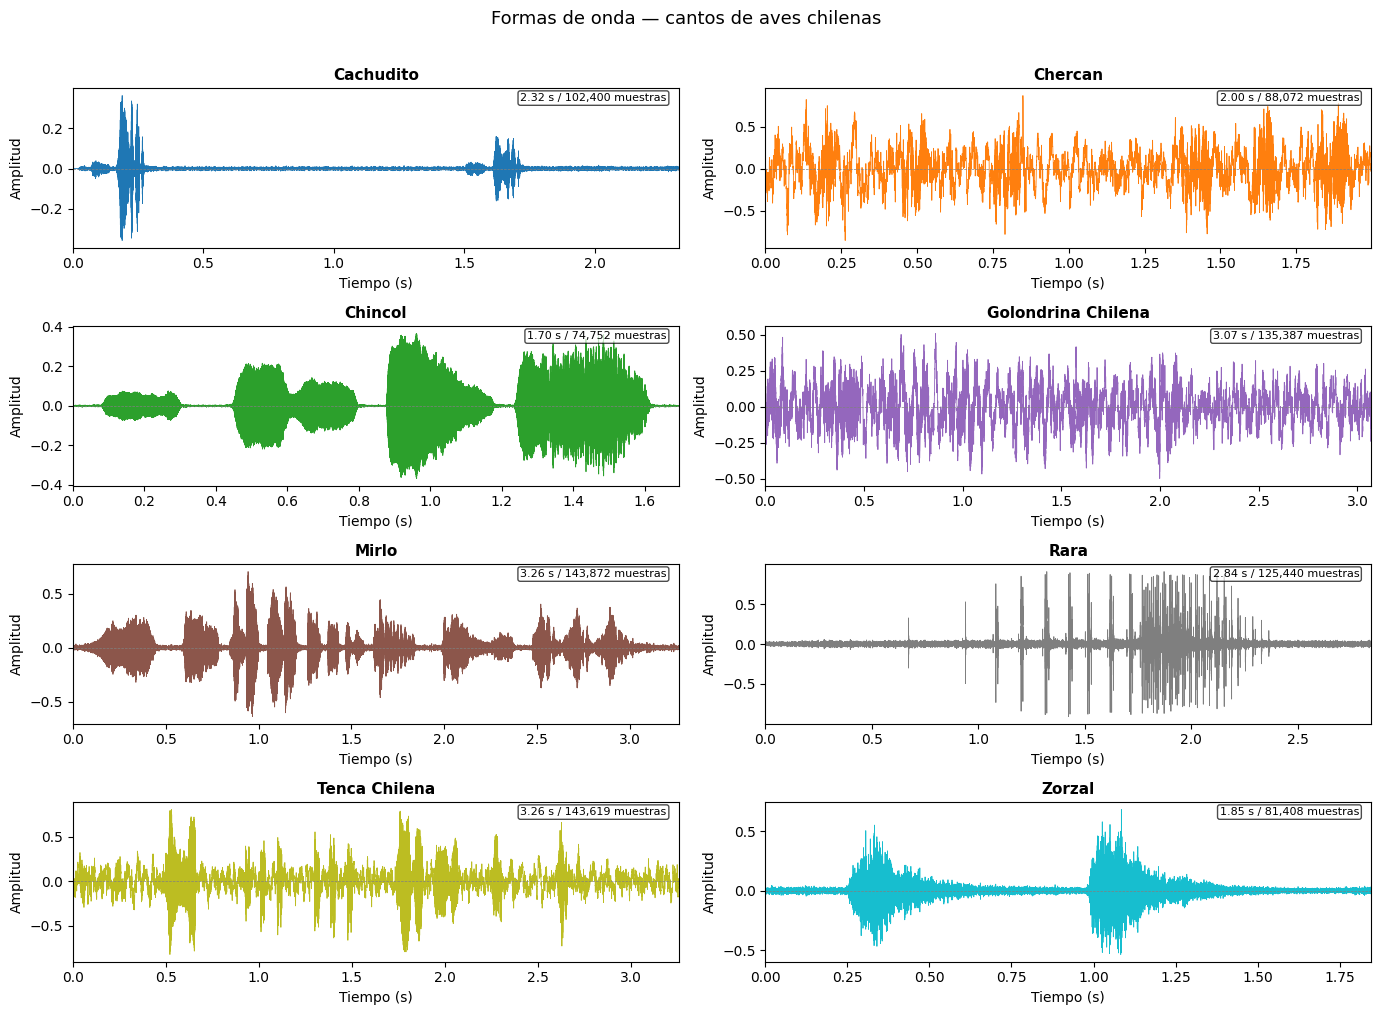

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(bird_audio)))

for ax, (name, y), color in zip(axes, bird_audio.items(), colors):
    t = np.arange(len(y)) / SR
    ax.plot(t, y, linewidth=0.6, color=color)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Amplitud')
    ax.set_xlim([0, t[-1]])
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    # Anotar la duración
    dur = len(y) / SR
    ax.text(0.98, 0.92, f'{dur:.2f} s / {len(y):,} muestras',
            transform=ax.transAxes, ha='right', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

plt.suptitle('Formas de onda — cantos de aves chilenas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. El problema

Observemos con claridad las diferencias de longitud entre las grabaciones. Cada ave produce un canto de duración distinta, lo que se traduce en vectores de distinta dimensión.

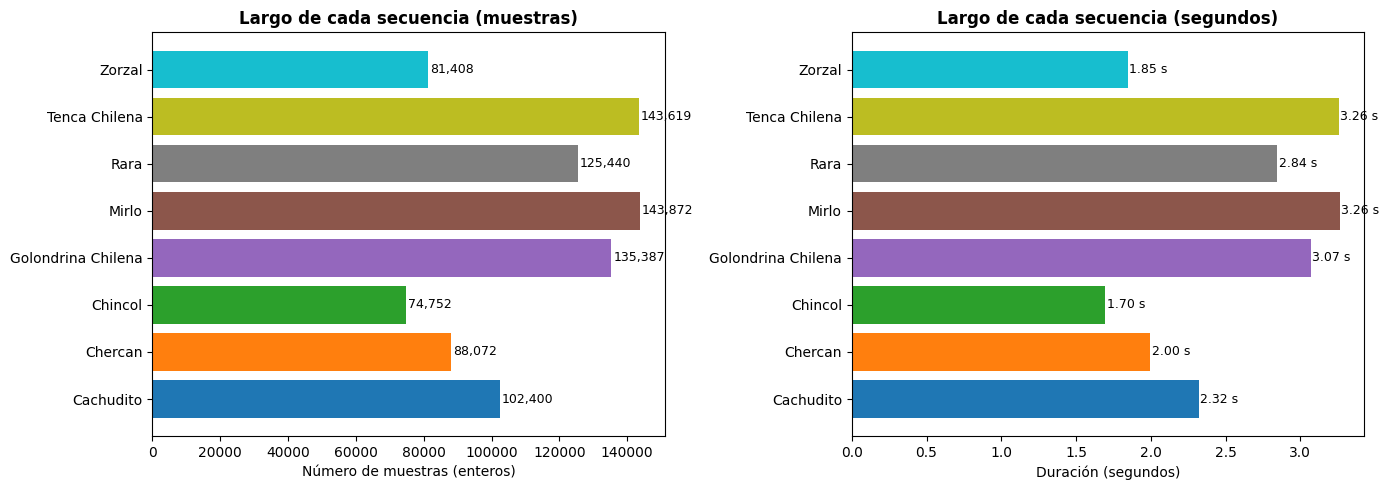

Secuencia más larga : Mirlo (143,872 muestras)
Secuencia más corta : Chincol (74,752 muestras)
Razón max/min       : 1.9x


In [4]:
lengths = {name: len(y) for name, y in bird_audio.items()}
names   = list(lengths.keys())
sizes   = list(lengths.values())
durations = [s / SR for s in sizes]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico de barras: número de muestras ──
bars = axes[0].barh(names, sizes, color=colors)
axes[0].set_xlabel('Número de muestras (enteros)')
axes[0].set_title('Largo de cada secuencia (muestras)', fontweight='bold')
for bar, val in zip(bars, sizes):
    axes[0].text(val + 500, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# ── Gráfico de barras: duración en segundos ──
bars2 = axes[1].barh(names, durations, color=colors)
axes[1].set_xlabel('Duración (segundos)')
axes[1].set_title('Largo de cada secuencia (segundos)', fontweight='bold')
for bar, val in zip(bars2, durations):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f} s', va='center', fontsize=9)

plt.tight_layout()
plt.show()

max_name = max(lengths, key=lengths.get)
min_name = min(lengths, key=lengths.get)
print(f'Secuencia más larga : {max_name} ({lengths[max_name]:,} muestras)')
print(f'Secuencia más corta : {min_name} ({lengths[min_name]:,} muestras)')
print(f'Razón max/min       : {lengths[max_name]/lengths[min_name]:.1f}x')

## 3. Usando *padding*

Una forma de forzar el ingreso de estas secuencias a un MLP es **igualar todos los vectores al largo máximo**, rellenando con ceros las posiciones faltantes. Esto se llama *zero-padding*.

Visualicemos el efecto: la zona en gris representa los ceros artificiales añadidos.

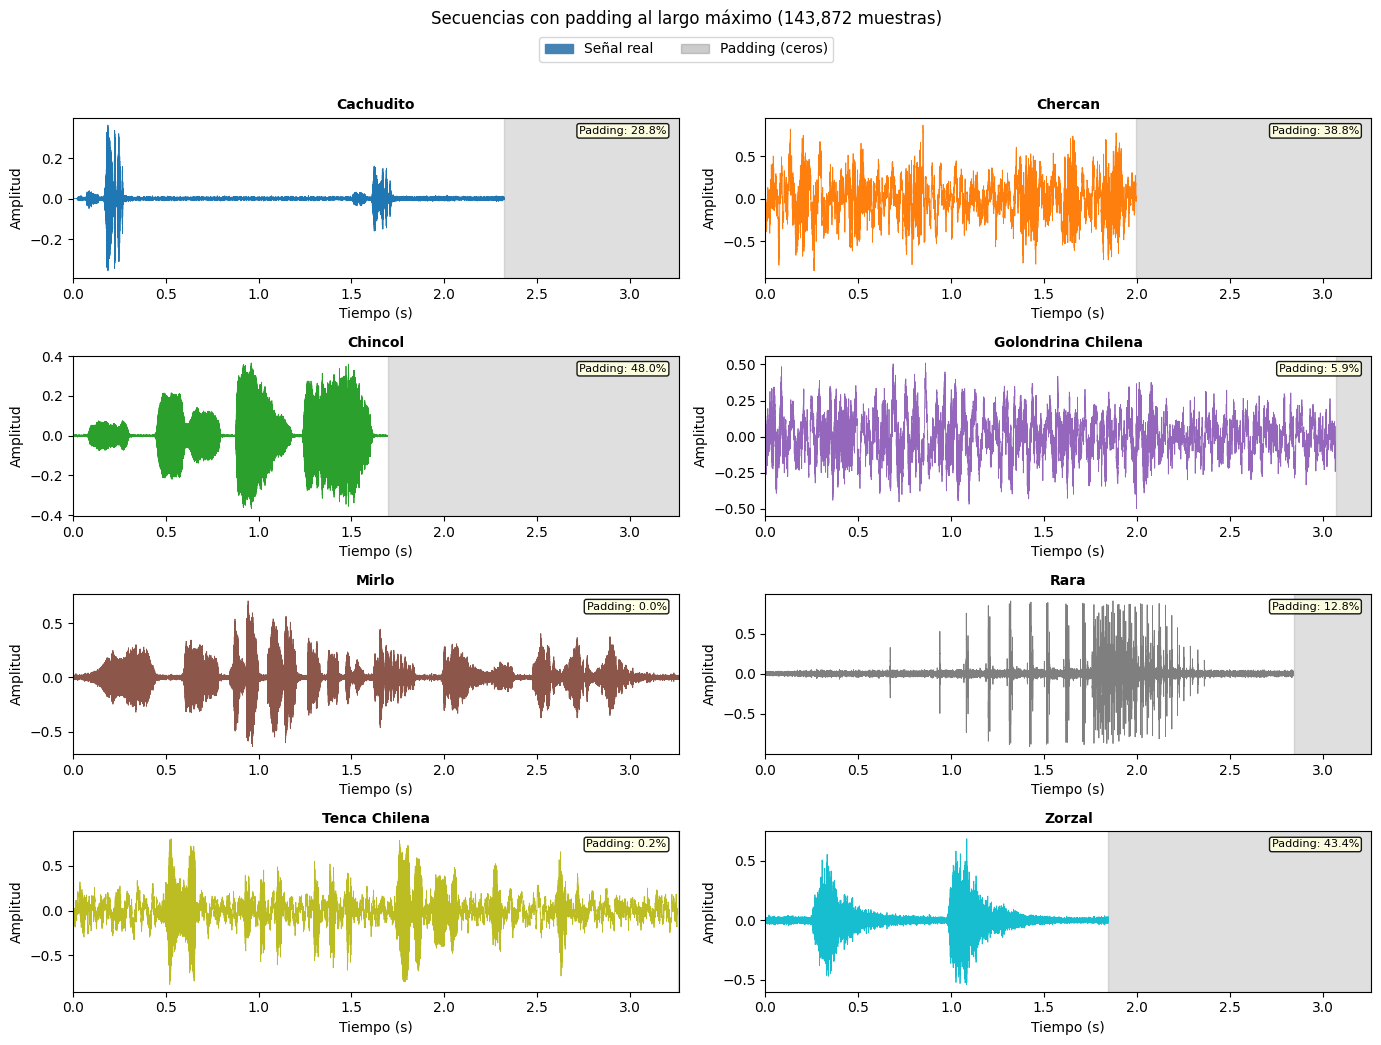

In [5]:
max_len = max(len(y) for y in bird_audio.values())

fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, y), color in zip(axes, bird_audio.items(), colors):
    # Señal original
    t_orig = np.arange(len(y)) / SR
    ax.plot(t_orig, y, linewidth=0.6, color=color, label='Señal real')

    # Zona de padding
    pad_start = len(y) / SR
    pad_end   = max_len / SR
    ax.axvspan(pad_start, pad_end, alpha=0.25, color='grey', label='Padding (ceros)')

    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlim([0, pad_end])
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Amplitud')

    pct_padding = (max_len - len(y)) / max_len * 100
    ax.text(0.98, 0.90, f'Padding: {pct_padding:.1f}%',
            transform=ax.transAxes, ha='right', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.9))

# Leyenda global
handles = [
    mpatches.Patch(color='steelblue', label='Señal real'),
    mpatches.Patch(color='grey',      alpha=0.4, label='Padding (ceros)'),
]
fig.legend(handles=handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))

plt.suptitle(f'Secuencias con padding al largo máximo ({max_len:,} muestras)', fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

## 4. Cantidad de parámetros en un MLP con padding

Construyamos un MLP sencillo de dos capas ocultas e investiguemos cuántos parámetros necesitaría si usáramos el largo máximo como entrada fija.

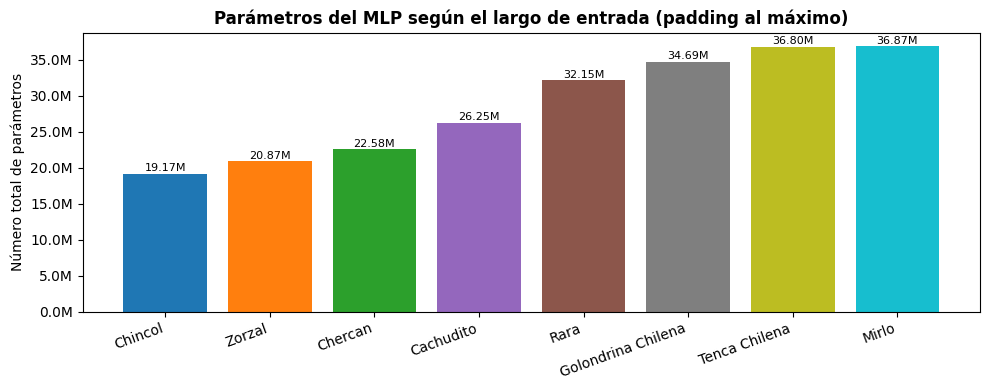

Con padding al máximo (143,872 muestras), el MLP necesita: 36,865,416 parámetros
Con la secuencia más corta (74,752 muestras):  19,170,696 parámetros
Diferencia: 17,694,720 parámetros extra solo por el padding


In [6]:
hidden_1 = 256
hidden_2 = 128
n_classes = len(bird_audio)   # 8 aves

input_sizes = sorted(lengths.values())
param_counts = []

for inp in input_sizes:
    # Capa 1: inp -> hidden_1
    p1 = inp * hidden_1 + hidden_1
    # Capa 2: hidden_1 -> hidden_2
    p2 = hidden_1 * hidden_2 + hidden_2
    # Capa salida: hidden_2 -> n_classes
    p3 = hidden_2 * n_classes + n_classes
    param_counts.append(p1 + p2 + p3)

fig, ax = plt.subplots(figsize=(10, 4))
sorted_names = [k for k, _ in sorted(lengths.items(), key=lambda x: x[1])]
bars = ax.bar(sorted_names, param_counts, color=colors)
ax.set_ylabel('Número total de parámetros')
ax.set_title('Parámetros del MLP según el largo de entrada (padding al máximo)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for bar, p in zip(bars, param_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5e4,
            f'{p/1e6:.2f}M', ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

max_params = max(param_counts)
min_params = min(param_counts)
print(f'Con padding al máximo ({max_len:,} muestras), el MLP necesita: {max_params:,} parámetros')
print(f'Con la secuencia más corta ({min(lengths.values()):,} muestras):  {min_params:,} parámetros')
print(f'Diferencia: {(max_params - min_params):,} parámetros extra solo por el padding')

## 5. El MLP ignora el orden

El problema más grave del padding no es el exceso de parámetros, sino que **un MLP trata cada muestra de entrada como si fuera independiente**. No existe noción de *antes* ni *después*: la muestra en $t=0$ y la muestra en $t=500$ son simplemente la neurona 0 y la neurona 500 de la capa de entrada, sin relación entre ellas.

Para ilustrarlo, permutemos aleatoriamente las muestras de un canto.

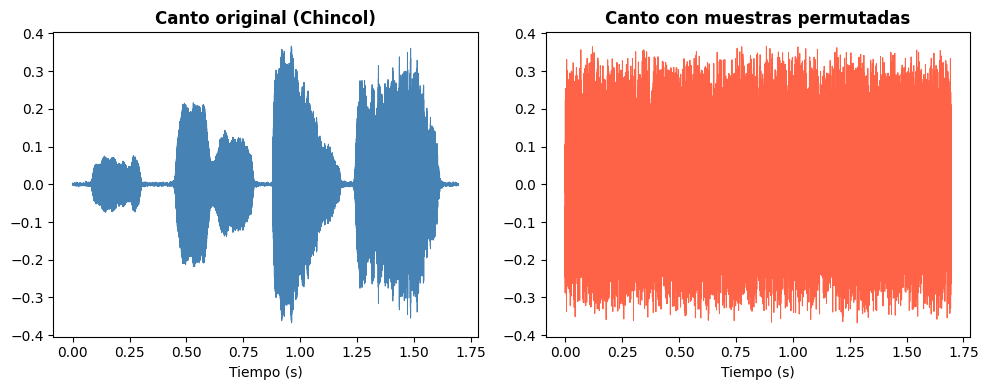

In [13]:
torch.manual_seed(42)
np.random.seed(42)

# Usamos el chincol (secuencia más corta) para el ejemplo
y_chincol  = torch.tensor(bird_audio['Chincol'], dtype=torch.float32)
n_samples  = len(y_chincol)

# Permutación aleatoria de las muestras
perm_idx          = torch.randperm(n_samples)
y_chincol_shuffled = y_chincol[perm_idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

t = np.arange(n_samples) / SR
axes[0].plot(t, y_chincol.numpy(),  color='steelblue', linewidth=0.7)
axes[0].set_title('Canto original (Chincol)', fontweight='bold')
axes[0].set_xlabel('Tiempo (s)')

axes[1].plot(t, y_chincol_shuffled.numpy(), color='tomato', linewidth=0.7)
axes[1].set_title('Canto con muestras permutadas', fontweight='bold')
axes[1].set_xlabel('Tiempo (s)')


plt.tight_layout()
plt.show()


## 6. La información real reside en la estructura temporal

Para convencernos de que el **orden importa**, comparemos los espectrogramas Mel (representaciones tiempo-frecuencia) del canto original y del permutado. El espectrograma captura cuánta energía hay en cada frecuencia en cada instante de tiempo.

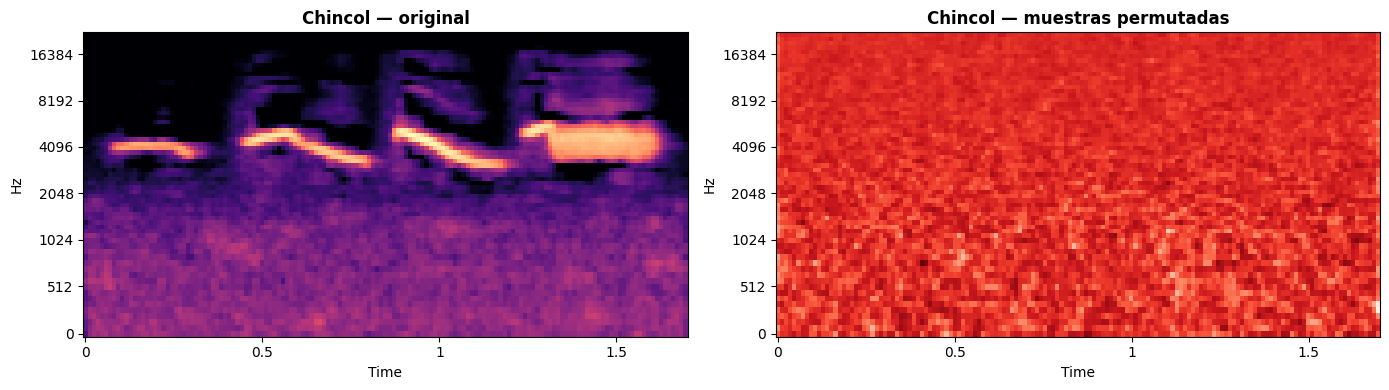

El patrón temporal característico del chincol (tres notas ascendentes) desaparece
completamente al permutar las muestras. El MLP, en cambio, no percibe esta diferencia.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

def plot_mel(ax, signal, sr, title, color_map='magma'):
    S = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=64)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel',
                                   sr=sr, ax=ax, cmap=color_map)
    ax.set_title(title, fontweight='bold')
    return img

plot_mel(axes[0], bird_audio['Chincol'],             SR, 'Chincol — original')
plot_mel(axes[1], y_chincol_shuffled.numpy(), SR, 'Chincol — muestras permutadas', 'Reds')

plt.tight_layout()
plt.show()

print('El patrón temporal característico del chincol (tres notas ascendentes) desaparece')
print('completamente al permutar las muestras. El MLP, en cambio, no percibe esta diferencia.')

## Pregunta

<font color="green">Observa los espectrogramas </font>  

<font color="green">1. ¿Por qué el espectrograma del chincol permutado se ve como ruido, si contiene los mismo valores numéricos, solo que en otro orden? </font>

<font color="green">2. ¿Qué información se ha perdido al permutar las muestras?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
El espectrograma es una representación tiempo-frecuencia: muestra qué frecuencias aparecen
<em>en qué momento</em>. Al permutar las muestras a nivel de muestra individual (44,100 veces
por segundo), las frecuencias que conforman cada nota del canto quedan repartidas al azar a
lo largo del tiempo. El contenido de frecuencias global permanece igual (el histograma de
amplitudes es el mismo), pero su <strong>ordenamiento temporal</strong> desaparece. Por eso el
espectrograma original muestra las tres notas ascendentes características del chincol,
mientras que el permutado luce como ruido blanco. El MLP con pesos fijos no puede distinguir
ambos casos porque no tiene acceso a este orden.
</p>
</details>

